In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
from matplotlib import pyplot
import dateutil 
from datetime import datetime, timedelta
import plotly.graph_objects as go
import importlib
import utils  
importlib.reload(utils)
from utils import * 



In [2]:
# home = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu/"
# downloads = "C:/Users/maksi/Documents/Statistics/Projects/Avian_Flu_Files/"
home = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu/"
downloads = "C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/" 
# originals = downloads + "Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--10-03-2025_Antarctica_North_America_South_America/"
originals = downloads + "Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--01-02-2026_Antarctica_North_America_South_America/"
# new_B3_13 = downloads + "Combinations/GISAID_Andersen_NCBI_Virus/11-01-2021--06-05-2025_B3_13/"
# new_D1_1 = downloads + "Combinations/GISAID_Andersen_NCBI_Virus/11-01-2021--06-05-2025_D1_1/"
# cat_files = downloads + "Cats/"

os.chdir(home + "references/")
animals_ref = pd.read_csv("animals_ref.csv")
states_ref = pd.read_csv("states_ref.csv")

In [3]:
os.chdir(originals)
mammal_genotypes = set()
file_names = []
for dirpath, dirs, files in os.walk(originals):
    for file in files:
        file_name = os.path.join(dirpath, file)
        if "PB2" in file_name and ".fasta" in file_name: # All metadata should be same
            with open(file_name) as f:
                lines = f.readlines()
                for line in lines:
                    if "feline" or "mammal" in line:
                        print(file_name)
                        mammal_genotypes.add(line.split("|")[-1]) # The genotype
                        if file_name not in file_names:
                            file_names.append(file_name) # The name of the file
                        # print(line)
                        # break 
                        # if len(line.split("|")) > 6:
                        #     line = line.replace(line.split("|")[0])[1:]
                        #     dfs[file_name] = fasta_df_og(file_name, states_ref)
                        # else:
                        # dfs[file_name] = fasta_df_complete(file_name, states_ref)
                        break 

print(mammal_genotypes)

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--01-02-2026_Antarctica_North_America_South_America/A1_PB2_11-01-2021--01-02-2026.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--01-02-2026_Antarctica_North_America_South_America/A2_PB2_11-01-2021--01-02-2026.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--01-02-2026_Antarctica_North_America_South_America/A3_PB2_11-01-2021--01-02-2026.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--01-02-2026_Antarctica_North_America_South_America/A4_PB2_11-01-2021--01-02-2026.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--01-02-2026_Antarctica_North_America_South_America/A5_PB2_11-01-2021--01-02-2026.fasta
C:/Users/maksiaevai.NCBI_NT/Documents/Av

In [124]:
dfs = {}
for dirpath, dirs, files in os.walk(originals):
    for file_name in file_names:
        df = fasta_df_complete(file_name, states_ref)
        mammal_df = df[(df["Host_Type"] == "other_mammal") | (df["Host_Type"] == "feline")]
        mammal_df = mammal_df.dropna()
        if len(mammal_df) > 0:
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.lower().replace(" ", "_"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("feline", "cat"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("feral_cat", "cat"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("domestic_cat", "cat"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("cougar", "mountain_lion"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("leo", "lion"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("panthera_lion", "lion"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("vulpes", "fox"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("seal", "pinniped"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("sea_lion", "pinniped"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.replace("flavescens", "pinniped"))
            mammal_df["Species"] = mammal_df["Species"].apply(lambda x: x.split("_")[-1] if ("lion" not in x and "cat" not in x) else "_".join(x.split("_")[-2:]))
            mammal_df = mammal_df[(mammal_df["Species"] != "swine") & (mammal_df["Species"] != "macaque")]
            dfs[file_name] = mammal_df
        
    break 

EPI_ISL_20151597|2024-09-20|H5N1|Gough_Island|2024-09-20|other|B3.2
EPI_ISL_20151596|2024-09-20|H5N1|Gough_Island|2024-09-09|other|B3.2


In [125]:
print(list(dfs.keys())[0])

mega_df = pd.DataFrame(columns=dfs[list(dfs.keys())[0]].columns)
for key in dfs.keys():
    df = dfs[key]
    genotype = key.split("/")[-1].split("_")[0]
    df["Genotype"] = genotype # Must all say same genotype, even if "Not assigned..." --> "Unassigned"
    print(genotype)
    # print(df)
    mega_df = pd.concat([mega_df, df], ignore_index=True)

print(mega_df)
    

C:/Users/maksiaevai.NCBI_NT/Documents/Avian_Flu_Files/Combinations/NCBI_Virus_Andersen_GISAID/11-01-2021--01-02-2026_Antarctica_North_America_South_America/A2_PB2_11-01-2021--01-02-2026.fasta
A2
A3
A5
A6
B1.1
B1.2
B1.3
B2.1
B3.13
B3.1
B3.2
B3.5
B3.6
B3.7
B4.1
C2.1
C3.1
D1.1
D1.2
Minor01
Minor15
Unassigned
                                                Header       Isolate_Id  \
0    EPI_ISL_19273373|A/Harbor_Seal/QC/FAV-0836-7/2...       FAV-0836-7   
1    EPI_ISL_14098919|A/harbor_seal/Maine/22-020455...    22-020455-005   
2    EPI_ISL_14098918|A/harbor_seal/Maine/22-020455...    22-020455-004   
3    EPI_ISL_14098917|A/harbor_seal/Maine/22-020455...    22-020455-003   
4    EPI_ISL_14098916|A/harbor_seal/Maine/22-020455...    22-020455-002   
..                                                 ...              ...   
934  SRR36628873|A/raccoon/United_States/24-036161-...    24-036161-001   
935  SRR36628744|A/eastern_gray_squirrel/United_Sta...    25-000865-001   
936  PV301414|A/Re

Genotype          A2   A3   A5   A6  B1.1  B1.2  B1.3  B2.1  B3.1  B3.13  ...  \
Species                                                                   ...   
alpaca           0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0    4.0  ...   
bear             4.0  1.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0    0.0  ...   
bobcat           0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0    2.0  ...   
cat              0.0  1.0  0.0  1.0   0.0   0.0   0.0   0.0   0.0  141.0  ...   
cheetah          0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0    0.0  ...   
chungungo        0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0    0.0  ...   
coyote           0.0  0.0  0.0  0.0   0.0   1.0   0.0   0.0   0.0    0.0  ...   
dog              0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0    0.0  ...   
dolphin          0.0  0.0  0.0  0.0   0.0   1.0   2.0   0.0   0.0    0.0  ...   
ermine           0.0  0.0  0.0  0.0   0.0   0.0   0.0   0.0   0.0    0.0  ...   
fox             10.0  6.0  6

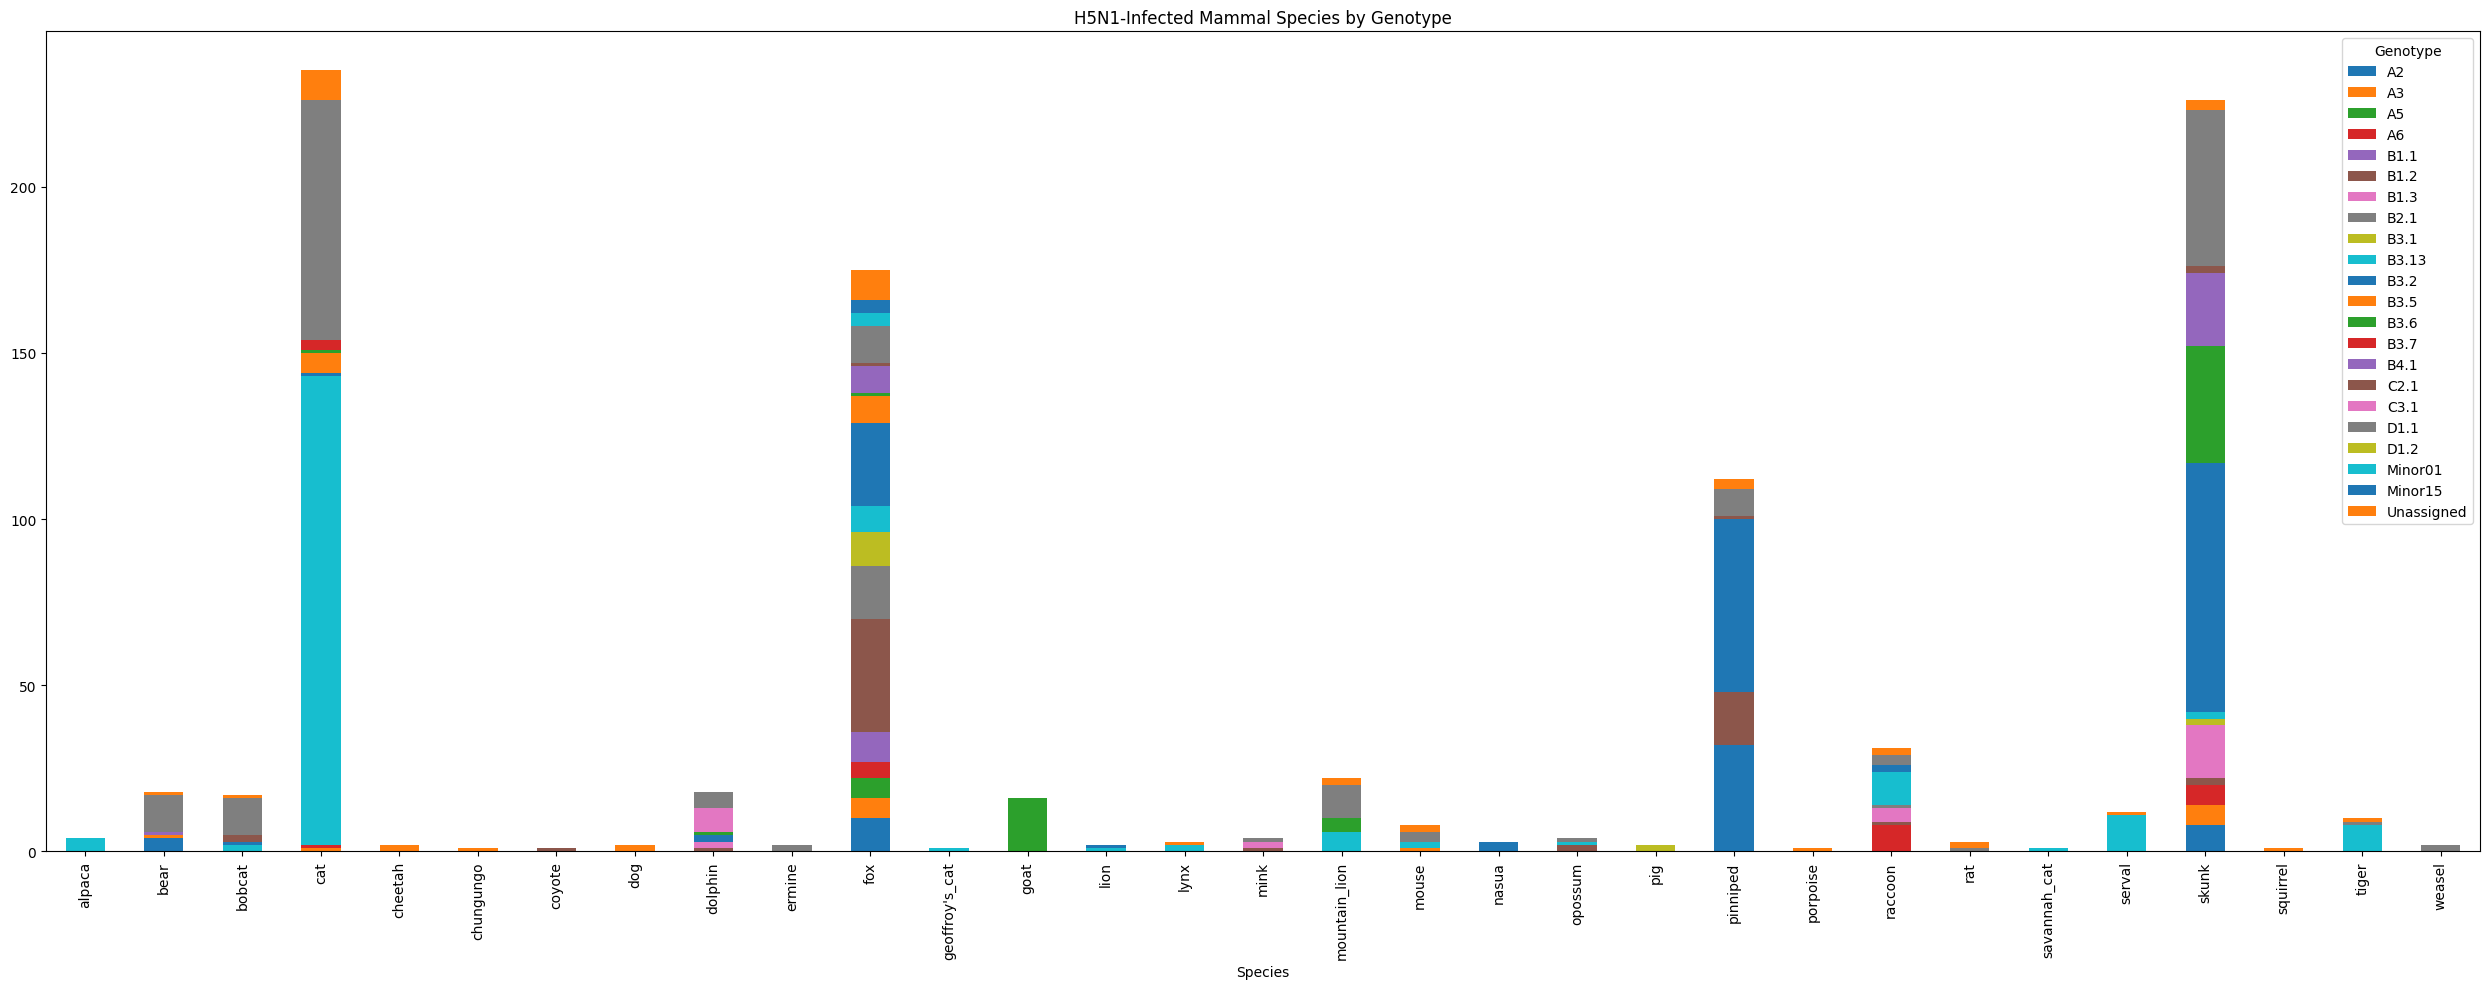

In [126]:
# index = pd.MultiIndex.from_frame(mega_df[["Species", "Genotype"]])
# multi_df = mega_df.groupby(by=["Species", "Genotype"]).count().reindex(index)
# multi_df["Genotype"] = multi_df.index.get_level_values("Genotype")
# print(multi_df)
# grouped_df = mega_df.groupby(by=["Species", "Genotype"], as_index=False).count()
# # print(grouped_df)

# # grouped_df = multi_df.groupby(level="Species").sum()

# grouped_df[["Species", "Genotype", "Header"]] #.plot(x="Species", kind='bar', stacked=True, title='Stacked Bar Graph')

df2 = mega_df.groupby(['Species', 'Genotype'])['Species'].count().unstack('Genotype').fillna(0)
print(df2)
fig, ax = pyplot.subplots(figsize=(25, 10))
df2.plot(kind='bar', stacked=True, ax=ax, title="H5N1-Infected Mammal Species by Genotype")
pyplot.tight_layout()

os.chdir(downloads)
fig.savefig("Species_Genotype_Other_Mammal.png")
df2.to_csv("species_genotype_other_mammal.csv")